## Semantic Search Ready NLP Pipeline (End-to-End)

This notebook builds a complete NLP preprocessing and semantic similarity pipeline from raw text using:

NLTK (stopwords, basic tokenization utilities)
spaCy (lemmatization)
scikit-learn (BoW/TF‑IDF + cosine similarity)
Gensim (Word2Vec + Doc2Vec sentence embeddings)

In [ ]:
# Install and import dependencies
# Download language models/resources

!pip -q install datasets spacy gensim wordcloud umap-learn
!python -m spacy download en_core_web_sm -q

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import nltk
nltk.download("stopwords")
nltk.download("punkt")

from nltk.corpus import stopwords

import spacy
nlp = spacy.load("en_core_web_sm")

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

from wordcloud import WordCloud
import umap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 31.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Step 1 — Load raw text data (HuggingFace Dataset)

We load a HuggingFace datasets both for reviews and comments and keep a manageable sample size for Colab runtime.

In [ ]:
# 1) Load Dataset (HuggingFace) — Merge Reviews + Comments
# Reviews: yelp_polarity
# Comments: civil_comments
# Creates a single corpus with a 'source' column

from datasets import load_dataset
import pandas as pd

# Reviews dataset
reviews_ds = load_dataset("yelp_polarity")["train"]
df_reviews = pd.DataFrame(reviews_ds).sample(n=4000, random_state=42).reset_index(drop=True)
df_reviews = df_reviews.rename(columns={"text": "text"})
df_reviews["source"] = "review"
df_reviews["label"] = df_reviews["label"]

# Comments dataset
comments_ds_all = load_dataset("civil_comments")
split_name = "train" if "train" in comments_ds_all else list(comments_ds_all.keys())[0]
comments_ds = comments_ds_all[split_name]
df_comments = pd.DataFrame(comments_ds).sample(n=4000, random_state=42).reset_index(drop=True)

df_comments = df_comments.rename(columns={"text": "text"})
df_comments["source"] = "comment"

# Create a simple label for visualization if toxicity exists
if "toxicity" in df_comments.columns:
    df_comments["label"] = (df_comments["toxicity"] >= 0.5).astype(int)
else:
    df_comments["label"] = 0

# Merge
df = pd.concat([df_reviews[["text","label","source"]], df_comments[["text","label","source"]]], ignore_index=True)
TEXT_COL = "text"
LABEL_COL = "label"
print("Combined dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Combined dataset shape: (8000, 3)


,text,label,source
0,This place is one of my favorite comic shops. ...,1,review
1,The wait time for an appointment is ridiculous...,0,review
2,I did not like this hotel at all. It's very ol...,0,review
3,Mill Avenue has a serious issue with parking. ...,1,review
4,Favorite sushi place in NV! Price is reasonab...,1,review


## Step 2 — Explore the data (EDA)

We inspect sample text, length distribution, and label balance to understand what we’re working with.

source
review     4000
comment    4000
Name: count, dtype: int64


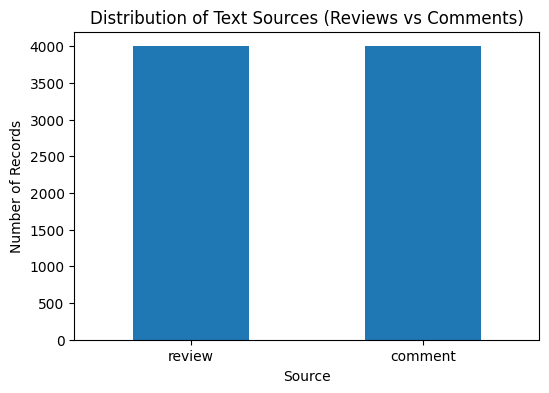

In [ ]:
# 2a) EDA: Distribution by source (reviews vs comments)
# Shows how much data comes from each source
# Useful to justify "media company: reviews + comments"

import matplotlib.pyplot as plt

# Print counts
print(df["source"].value_counts())

# Bar chart
plt.figure(figsize=(6,4))
df["source"].value_counts().plot(kind="bar")
plt.title("Distribution of Text Sources (Reviews vs Comments)")
plt.xlabel("Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

Label distribution:
 label
0    5759
1    2241
Name: count, dtype: int64

Word length summary:
 count    8000.000000
mean       93.780250
std       101.584741
min         1.000000
25%        27.000000
50%        61.000000
75%       127.000000
max       979.000000
Name: word_len, dtype: float64


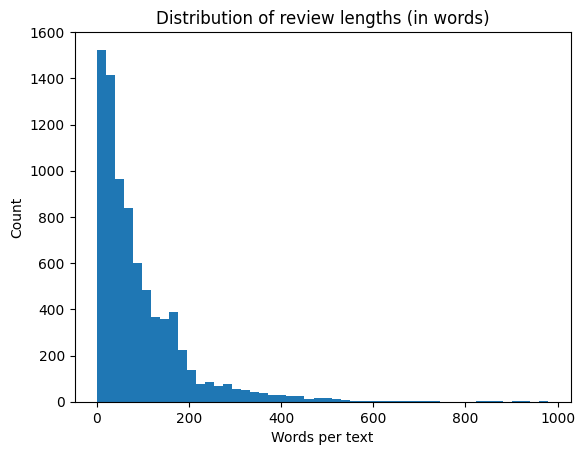


Sample raw texts:

--- Sample 1 ---
This place is one of my favorite comic shops. I actually live closer to a different one, but I drive to chandler just to go to this one. I like their selection and when they have the dollar sale you can get some ridiculous deals. The staff is ridiculously friendly and I usually always walk out with whatever I wanted. They also have some cool events from time to time and i've found their prices to 

--- Sample 2 ---
The wait time for an appointment is ridiculous. Been waiting over an hour and a half for my scheduled appointment time. These people do not value patients time

--- Sample 3 ---
I did not like this hotel at all. It's very old and not comforts in it. \nThe good thing is that it was cheap but at the time was like a room just to sleep! \nThere is no view at all and while you are in the Vegas it should not be those kind of rooms. \nWhen we came in to the room we just sow a trash cans and an a conditioner staff...!!!\nBut the Casino and staff 

In [ ]:
# 2b) Exploratory Data Analysis (EDA)
# Check label distribution
# Compute text length stats
# Visualize length distribution

df["char_len"] = df[TEXT_COL].astype(str).apply(len)
df["word_len"] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print("Label distribution:\n", df[LABEL_COL].value_counts())
print("\nWord length summary:\n", df["word_len"].describe())

plt.figure()
plt.hist(df["word_len"], bins=50)
plt.title("Distribution of review lengths (in words)")
plt.xlabel("Words per text")
plt.ylabel("Count")
plt.show()

print("\nSample raw texts:")
for i in range(3):
    print(f"\n--- Sample {i+1} ---\n{df.loc[i, TEXT_COL][:400]}")

## Step 3 — Text Cleaning

We normalize text: lowercase, remove URLs, remove special characters, collapse whitespace.

In [ ]:
# 3) Text Cleaning
# Define a cleaning function
# Apply to dataset
# Show before/after examples

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text) # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)         # keep letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()      # collapse whitespace
    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)

print("Before:\n", df.loc[0, TEXT_COL][:300])
print("\nAfter:\n", df.loc[0, "clean_text"][:300])

Before:
 This place is one of my favorite comic shops. I actually live closer to a different one, but I drive to chandler just to go to this one. I like their selection and when they have the dollar sale you can get some ridiculous deals. The staff is ridiculously friendly and I usually always walk out with 

After:
 this place is one of my favorite comic shops i actually live closer to a different one but i drive to chandler just to go to this one i like their selection and when they have the dollar sale you can get some ridiculous deals the staff is ridiculously friendly and i usually always walk out with what


## Step 4 — Tokenization, Stopword Removal, Lemmatization

We use spaCy for tokenization + lemmatization, and NLTK stopwords for filtering.

In [ ]:
# 4) Tokenize + Stopword Removal + Lemmatize
# Use spaCy pipeline
# Keep alphabetic tokens only
# Remove stopwords
# Lemmatize tokens

def spacy_lemmatize(text: str):
    doc = nlp(text)
    tokens = []
    for t in doc:
        if t.is_alpha:
            lemma = t.lemma_.lower().strip()
            if lemma and lemma not in STOP_WORDS:
                tokens.append(lemma)
    return tokens

df["tokens"] = df["clean_text"].apply(spacy_lemmatize)
df["processed_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

print("Processed sample:\n", df.loc[0, "processed_text"][:300])
print("\nTokens sample:\n", df.loc[0, "tokens"][:40])

Processed sample:
 place one favorite comic shop actually live close different one drive chandler go one like selection dollar sale get ridiculous deal staff ridiculously friendly usually always walk whatever want also cool event time time find price reasonable comparable comic shop

Tokens sample:
 ['place', 'one', 'favorite', 'comic', 'shop', 'actually', 'live', 'close', 'different', 'one', 'drive', 'chandler', 'go', 'one', 'like', 'selection', 'dollar', 'sale', 'get', 'ridiculous', 'deal', 'staff', 'ridiculously', 'friendly', 'usually', 'always', 'walk', 'whatever', 'want', 'also', 'cool', 'event', 'time', 'time', 'find', 'price', 'reasonable', 'comparable', 'comic', 'shop']


## Step 5 — Vocabulary Creation

We build vocabulary and show top frequent terms.

In [ ]:
# 5) Vocabulary Creation
# Build frequency distribution
# Display vocabulary size
# Show top-N frequent tokens

all_tokens = [tok for row in df["tokens"] for tok in row]
vocab_counter = Counter(all_tokens)

print("Vocabulary size:", len(vocab_counter))
print("\nTop 20 tokens:")
for w, c in vocab_counter.most_common(20):
    print(f"{w:>15} : {c}")

Vocabulary size: 23458

Top 20 tokens:
              n : 6161
            get : 3944
             go : 3514
           good : 3210
           like : 2673
          place : 2630
           time : 2464
           food : 2382
            one : 2343
          would : 2239
           make : 2080
           come : 1968
            say : 1909
           well : 1856
          order : 1786
          great : 1653
        service : 1651
           back : 1641
           take : 1615
            try : 1473


## Step 6 — Vectorization (Bag of Words (BoW) and TF‑IDF Vectors)

We build BoW and TF‑IDF representations using scikit-learn.

In [ ]:
# 6) BoW + TF-IDF Vectorization
# - Fit vectorizers on processed text
# - Show matrix shapes
# - Inspect feature names

corpus = df["processed_text"].tolist()

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(corpus)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)
print("\nExample features:", bow_vectorizer.get_feature_names_out()[:20])

BoW shape: (8000, 5000)
TF-IDF shape: (8000, 5000)

Example features: ['abandon' 'aber' 'abide' 'ability' 'able' 'aboriginal' 'abortion'
 'absolute' 'absolutely' 'absorb' 'abuse' 'ac' 'aca' 'academy' 'accent'
 'accept' 'acceptable' 'access' 'accident' 'accidentally']


## Step 7 — Word Embeddings (Gensim Word2Vec)

Train Word2Vec on tokenized text and inspect nearest neighbors.

In [ ]:
# 7) Word Embeddings (Word2Vec)
# Train Word2Vec on tokens
# Query similar words

sentences = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2,
    sg=1,          # skip-gram
    epochs=10,
    seed=42
)

print("Word2Vec vocab size:", len(w2v_model.wv.index_to_key))

# Try a few example terms that often exist in review data
for query_word in ["good", "bad", "service", "food"]:
    if query_word in w2v_model.wv:
        print(f"\nMost similar to '{query_word}':")
        print(w2v_model.wv.most_similar(query_word, topn=8))

Word2Vec vocab size: 9549

Most similar to 'good':
[('definite', 0.7174125909805298), ('ngood', 0.7110952138900757), ('cereal', 0.7068228721618652), ('snob', 0.7064204812049866), ('decently', 0.7041217088699341), ('lacking', 0.6999098062515259), ('dope', 0.699009120464325), ('ndrink', 0.6982817649841309)]

Most similar to 'bad':
[('terrible', 0.6672227382659912), ('horrible', 0.6519902944564819), ('horrendous', 0.6259792447090149), ('worst', 0.6236069798469543), ('crappy', 0.6169227361679077), ('lousy', 0.616723358631134), ('awful', 0.6024338006973267), ('pathetic', 0.5990850329399109)]

Most similar to 'service':
[('nfood', 0.6748162508010864), ('waitstaff', 0.6727679967880249), ('nservice', 0.6489839553833008), ('cleanliness', 0.6483625173568726), ('prompt', 0.6319580078125), ('unfriendly', 0.6316352486610413), ('amazingly', 0.6280404925346375), ('nstaff', 0.6273290514945984)]

Most similar to 'food':
[('nfood', 0.7390905022621155), ('ayce', 0.6982245445251465), ('mediocre', 0.695584

## Step 8 — Sentence Embeddings (Gensim Doc2Vec + Avg Word2Vec)

We build sentence embeddings in two ways:

1) Doc2Vec (learns document vectors directly)
2) Average Word2Vec (mean of word vectors in a text)

In [ ]:
# 8) Sentence Embeddings
# Train Doc2Vec
# Create Avg Word2Vec sentence vectors

# Doc2Vec expects TaggedDocument objects
tagged_docs = [TaggedDocument(words=toks, tags=[i]) for i, toks in enumerate(df["tokens"])]

doc2vec_model = Doc2Vec(
    documents=tagged_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=2,
    epochs=20,
    dm=1,      # distributed memory
    seed=42
)

doc_vectors = np.vstack([doc2vec_model.dv[i] for i in range(len(df))])
print("Doc2Vec sentence embedding matrix:", doc_vectors.shape)

# Average Word2Vec vectors for each document
def avg_w2v_vector(tokens, model, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

avgw2v_vectors = np.vstack([avg_w2v_vector(toks, w2v_model, 100) for toks in df["tokens"]])
print("Avg Word2Vec sentence embedding matrix:", avgw2v_vectors.shape)

Doc2Vec sentence embedding matrix: (8000, 100)
Avg Word2Vec sentence embedding matrix: (8000, 100)


## Step 9 — Similarity Search (TF‑IDF + Doc2Vec)

We create a simple semantic search function:

Convert a query to TF‑IDF vector and return most similar texts
Convert a query to Doc2Vec vector and return most similar texts

In [ ]:
# 9) Similarity Search
# Implement two retrieval methods:
#   A) TF-IDF cosine similarity
#   B) Doc2Vec inferred vector cosine similarity

def search_tfidf(query, top_k=5):
    q = clean_text(query)
    q_tokens = spacy_lemmatize(q)
    q_proc = " ".join(q_tokens)
    q_vec = tfidf_vectorizer.transform([q_proc])
    sims = cosine_similarity(q_vec, X_tfidf).ravel()
    idx = np.argsort(-sims)[:top_k]
    return idx, sims[idx]

def search_doc2vec(query, top_k=5):
    q = clean_text(query)
    q_tokens = spacy_lemmatize(q)
    q_vec = doc2vec_model.infer_vector(q_tokens, epochs=30)
    sims = cosine_similarity([q_vec], doc_vectors).ravel()
    idx = np.argsort(-sims)[:top_k]
    return idx, sims[idx]

def show_results(query, idx, scores, title):
    print(f"\n=== {title} ===")
    print("Query:", query)

    for rank, (i, s) in enumerate(zip(idx, scores), start=1):
        print(f"\n#{rank} | score={s:.4f}")

        # Print whether the matched text came from reviews or comments
        print("source:", df.loc[i, "source"])

        # Print the retrieved original text snippet
        raw = df.loc[i, TEXT_COL]
        print(raw[:350])


# Demo queries
queries = [
    "excellent customer service and friendly staff",
    "the food was terrible and overpriced",
    "waiting time was too long"
]

for q in queries:
    idx, sc = search_tfidf(q, top_k=3)
    show_results(q, idx, sc, "TF-IDF Similarity Search")

    idx, sc = search_doc2vec(q, top_k=3)
    show_results(q, idx, sc, "Doc2Vec Similarity Search")


=== TF-IDF Similarity Search ===
Query: excellent customer service and friendly staff

#1 | score=0.4662
source: review
Excellent food and even better service.

#2 | score=0.4361
source: review
Friendly service and great food.

#3 | score=0.4129
source: review
The gyro platter was excellent! Very friendly staff and quick efficient service. I can't wait to come back to town and try it again!

=== Doc2Vec Similarity Search ===
Query: excellent customer service and friendly staff

#1 | score=0.9671
source: comment
Nothing wrong with that.

#2 | score=0.9660
source: comment
Dopers Unite!

#3 | score=0.9628
source: comment
Ditto!

=== TF-IDF Similarity Search ===
Query: the food was terrible and overpriced

#1 | score=0.7398
source: review
Food sux. Overpriced. Wont come here again!

#2 | score=0.4773
source: review
$7+ for ONE piece of sushi! And how was it?  terrible, terrible!!!!

#3 | score=0.4015
source: review
the worst don't do it!!!! terrible service! terrible door man! 1961 decor-

## Step 10 — Insights & Visualization
We’ll visualize Top words (bar chart), WordCloud and 2D projection of sentence embeddings (UMAP)

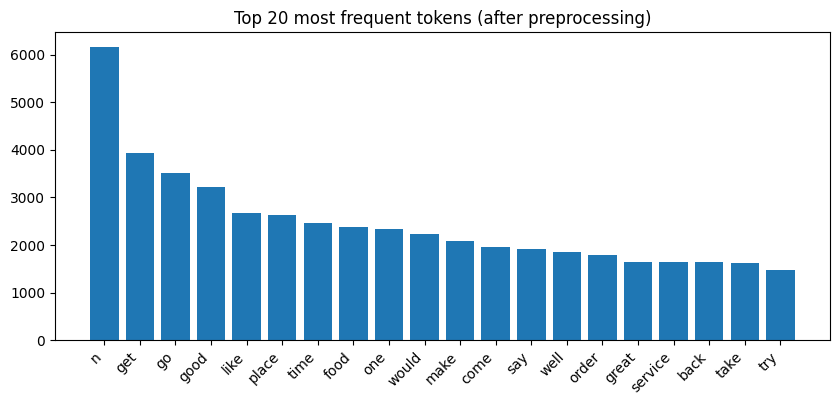

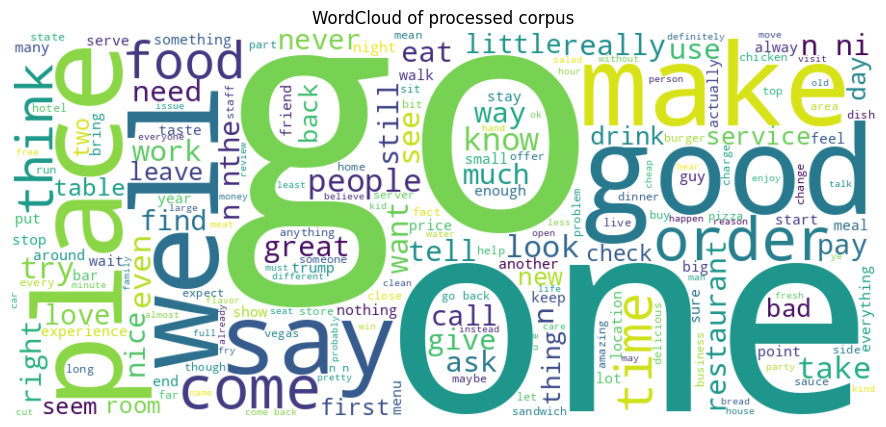

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


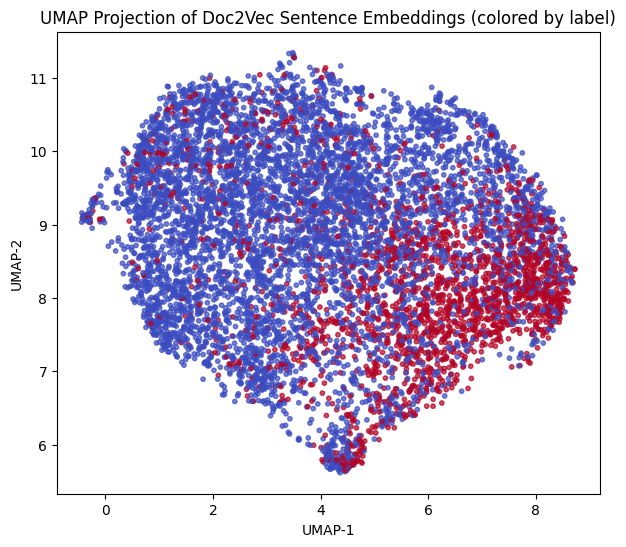

In [ ]:
# 10) Insights & Visualization
# Top frequent words
# WordCloud
# UMAP projection of sentence embeddings

# Top frequent words bar chart
top_words = vocab_counter.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10,4))
plt.bar(words, counts)
plt.title("Top 20 most frequent tokens (after preprocessing)")
plt.xticks(rotation=45, ha="right")
plt.show()

# WordCloud
wc_text = " ".join(df["processed_text"].tolist())
wordcloud = WordCloud(width=900, height=400, background_color="white").generate(wc_text)

plt.figure(figsize=(12,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of processed corpus")
plt.show()

# UMAP visualization (Doc2Vec embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
emb2d = reducer.fit_transform(doc_vectors)

plt.figure(figsize=(7,6))
plt.scatter(emb2d[:,0], emb2d[:,1], c=df[LABEL_COL], cmap="coolwarm", s=10, alpha=0.7)
plt.title("UMAP Projection of Doc2Vec Sentence Embeddings (colored by label)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

## Save Artifacts (vectorizers and models)

Saving artifacts makes your pipeline “production-like”.

In [ ]:
# Save Artifacts
# Save vectorizers and gensim models

import joblib

joblib.dump(bow_vectorizer, "bow_vectorizer.joblib")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")

w2v_model.save("word2vec.model")
doc2vec_model.save("doc2vec.model")

print("Saved: vectorizers + Word2Vec + Doc2Vec")

Saved: vectorizers + Word2Vec + Doc2Vec
